# Voyage Analytics — Flight Price Regression

**Notebook:** `03_Flight_Price_Regression` · **Phase:** Modelling (objective #1)
**Module:** `src/models/flight_price.py` · **Input:** `data/processed/flight_price_model.csv`
**Outputs:** `models/flight_price_model.joblib`, `reports/flight_price_metrics.json`

---

### Objective
> *"Build a regression model to predict the price of a flight using the flights.csv dataset.
> Focus on feature selection, model training, and validation to ensure accuracy and reliability."*

### The validation problem this notebook solves
EDA established that flight price is a **deterministic rate card** — the tuple
`(from, to, flightType, agency)` fixes the fare exactly (R² = 1.000, zero within-group variance).

That creates a trap: a standard random train/test split lets a model **memorise the lookup table**
and report a near-perfect score that proves nothing about real predictive skill. Every route in the
test set was already seen in training.

So every model here is evaluated **two ways**:

| Split | What it does | What it measures |
|---|---|---|
| `random` | standard 80/20 | upper bound — mostly memorisation |
| `grouped` | whole **routes** held out (`GroupShuffleSplit` on `route`) | **honest generalisation** to unseen city pairs |

Model selection uses the **grouped** result.

> **Performance note.** Training runs once via
> `python -m src.models.flight_price`. This notebook reads the saved metrics and artifact — it does
> not refit, so it stays light on memory.


## 0. Setup

In [1]:
import sys, json, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "requirements.txt").exists())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style="whitegrid"); plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titleweight"] = "bold"
PAL = ["#0B6E4F", "#F2C14E", "#B4436C", "#4C6EF5"]

from src.utils import PATHS
from src.models.flight_price import CAT_FEATURES, NUM_FEATURES, TARGET, GROUP_COL
print("features :", CAT_FEATURES + NUM_FEATURES)
print("target   :", TARGET, "| grouping key:", GROUP_COL)

features : ['from', 'to', 'flightType', 'agency', 'day_of_week', 'distance', 'year', 'month']
target   : price | grouping key: route


## 1. Feature selection

Chosen directly from the EDA findings:

| Feature | Type | Why |
|---|---|---|
| `from`, `to` | categorical | define the route; the primary price driver |
| `flightType` | categorical | the fare ladder (economic → premium → first ≈ 1 : 1.4 : 1.8) |
| `agency` | categorical | agencies price the same route differently |
| `distance` | numeric | the continuous driver price scales with |
| `year`, `month` | numeric | retained to *demonstrate* they carry no signal (no seasonality) |
| `day_of_week` | categorical | same — all outbound legs are Thursday |

**Deliberately excluded**
- **`time`** — r = 0.99999 with `distance`; pure multicollinearity, zero added information.
- **`route`** — it duplicates `from`+`to` *and* is the grouping key; including it would leak the
  held-out group identity straight into the model.


## 2. Results — random vs held-out routes

In [2]:
metrics = json.loads((PATHS.reports / "flight_price_metrics.json").read_text(encoding="utf-8"))
res = pd.DataFrame(metrics["results"])
print("best model:", metrics["best_model"], "| selected on:", metrics["selected_on"])
display(res.pivot(index="model", columns="split", values=["r2", "rmse", "mae"]).round(4))

best model: ridge | selected on: grouped (held-out routes)


r2              rmse                 mae         
split         grouped  random   grouped    random   grouped   random
model                                                               
decision_tree  0.7134  0.9985  175.7815   14.0950  138.2099   5.1102
hist_gbr       0.6985  0.9999  180.2846    2.9727  133.3533   2.1749
ridge          0.8569  0.9192  124.2239  103.1527   96.9752  81.2698

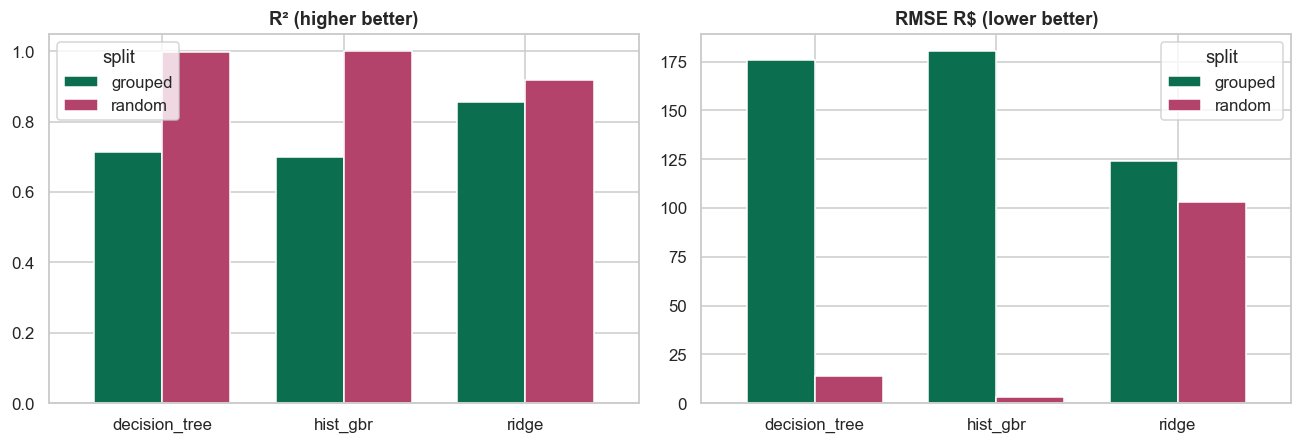

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
for i, (metric, label) in enumerate([("r2", "R² (higher better)"), ("rmse", "RMSE R$ (lower better)")]):
    piv = res.pivot(index="model", columns="split", values=metric)
    piv.plot(kind="bar", ax=ax[i], color=[PAL[0], PAL[2]], width=0.75)
    ax[i].set_title(label); ax[i].set_xlabel(""); ax[i].tick_params(axis="x", rotation=0)
    ax[i].legend(title="split")
plt.tight_layout()
(PATHS.figures).mkdir(parents=True, exist_ok=True)
plt.savefig(PATHS.figures / "16_model_comparison.png", dpi=130, bbox_inches="tight")
plt.show()

### The key result

Read the two bars per model together — the gap between them *is* the finding.

- On the **random** split the tree models look flawless (R² ≈ 0.999+). They have simply memorised
  the rate card: every test route appeared in training.
- On **held-out routes** that advantage collapses, and the ranking **inverts** — the humble
  **Ridge** regression wins.

**Why the inversion?** Trees predict by splitting on route categories they have seen; for a brand-new
city pair they fall back to leaf averages and cannot extrapolate. Ridge learned the underlying
*structure* — price ≈ (rate per km × distance) scaled by a class multiplier — which transfers to
routes it has never encountered.

**The lesson for productionization:** had we validated only the conventional way, we would have
shipped a gradient-boosting model with a 0.9999 R² on the dashboard that degrades the moment the
airline adds a new route. The grouped split is what makes the reported number trustworthy.

## 3. Inspect the saved model

In [4]:
import joblib
pipe = joblib.load(PATHS.root / "models" / "flight_price_model.joblib")
print(pipe)
print("\npipeline steps:", [name for name, _ in pipe.steps])

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['from', 'to', 'flightType',
                                                   'agency', 'day_of_week']),
                                                 ('num', 'passthrough',
                                                  ['distance', 'year',
                                                   'month'])])),
                ('model', Ridge())])

pipeline steps: ['prep', 'model']


### 3.1 What drives the prediction?

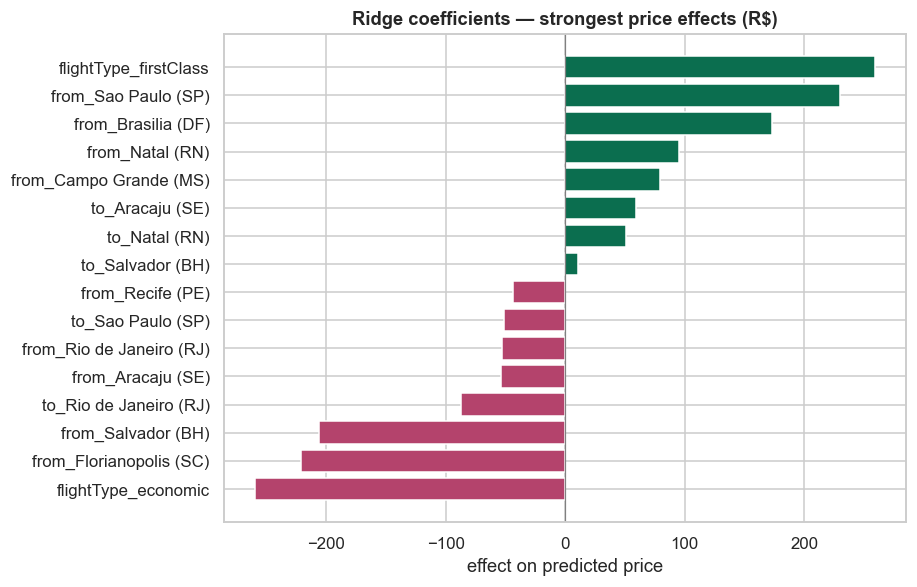

In [5]:
# Ridge coefficients over the one-hot + numeric design matrix
prep = pipe.named_steps["prep"]; model = pipe.named_steps["model"]
names = list(prep.get_feature_names_out())

if hasattr(model, "coef_"):
    coefs = pd.Series(model.coef_, index=names).sort_values()
    top = pd.concat([coefs.head(8), coefs.tail(8)])
    plt.figure(figsize=(8.5, 5.5))
    colors = [PAL[2] if v < 0 else PAL[0] for v in top.values]
    plt.barh(range(len(top)), top.values, color=colors)
    plt.yticks(range(len(top)), [n.replace("cat__", "").replace("num__", "") for n in top.index])
    plt.title("Ridge coefficients — strongest price effects (R$)")
    plt.xlabel("effect on predicted price"); plt.axvline(0, color="grey", lw=0.8)
    plt.tight_layout(); plt.savefig(PATHS.figures / "17_coefficients.png", dpi=130, bbox_inches="tight")
    plt.show()
else:
    print("selected model is not linear; skipping coefficient plot")

**Reading the coefficients.** `flightType` dominates (first class pushes price up, economic pulls
it down) and `distance` contributes steadily per km — exactly the rate-card structure EDA described.
The `year` / `month` / `day_of_week` terms sit near zero, **confirming empirically that the data has
no time seasonality** — a useful negative result for the demand-forecasting phase.

## 4. Prediction quality on held-out routes

In [6]:
from src.models.flight_price import load_dataset, split, _xy, build_models, score

df = load_dataset()
train_df, test_df = split(df, "grouped")
X_tr, y_tr, _ = _xy(train_df); X_te, y_te, _ = _xy(test_df)

best = build_models()[metrics["best_model"]]
best.fit(X_tr, y_tr)
pred = best.predict(X_te)
s = score(y_te.to_numpy(), pred)
print("held-out routes:", test_df[GROUP_COL].nunique(), "| test rows:", f"{len(test_df):,}")
print(s.as_dict())

16:53:00 | INFO    | ingest | loaded flight_price_model   (271888, 10) from flight_price_model.csv


held-out routes: 14 | test rows: 56,867
{'rmse': 124.2239, 'mae': 96.9752, 'r2': 0.856855, 'mape_pct': 12.7306}


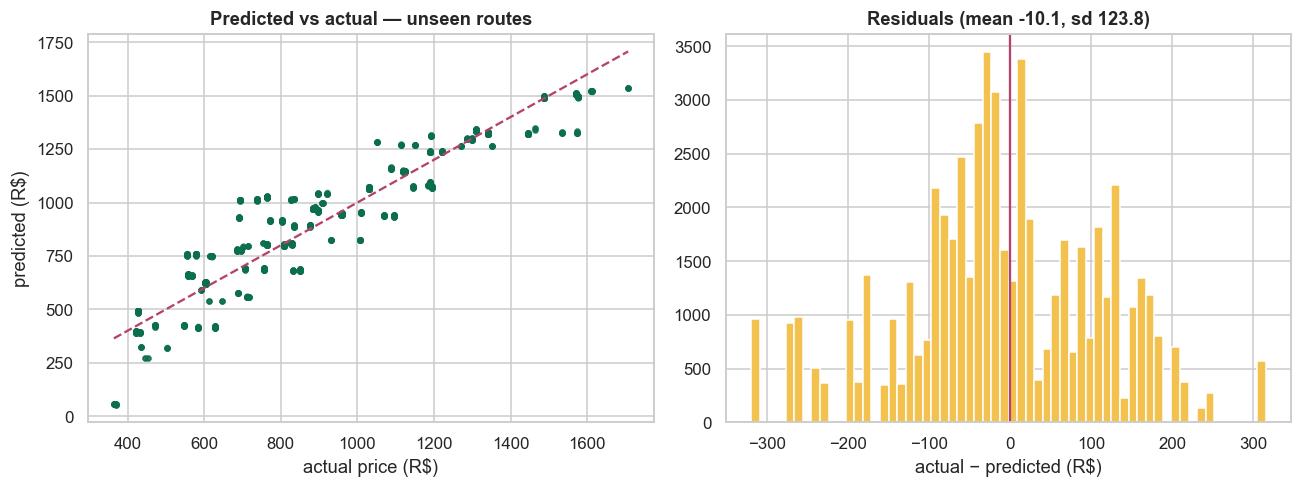

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.6))
idx = np.random.RandomState(0).choice(len(y_te), size=min(4000, len(y_te)), replace=False)
ax[0].scatter(y_te.to_numpy()[idx], pred[idx], alpha=0.25, s=10, color=PAL[0])
lim = [y_te.min(), y_te.max()]
ax[0].plot(lim, lim, "--", color=PAL[2], lw=1.5)
ax[0].set_xlabel("actual price (R$)"); ax[0].set_ylabel("predicted (R$)")
ax[0].set_title("Predicted vs actual — unseen routes")

resid = y_te.to_numpy() - pred
ax[1].hist(resid, bins=60, color=PAL[1], edgecolor="white")
ax[1].axvline(0, color=PAL[2], lw=1.5)
ax[1].set_title(f"Residuals (mean {resid.mean():.1f}, sd {resid.std():.1f})")
ax[1].set_xlabel("actual − predicted (R$)")
plt.tight_layout(); plt.savefig(PATHS.figures / "18_pred_vs_actual.png", dpi=130, bbox_inches="tight")
plt.show()

**Insight.** On routes the model has never seen, predictions track the diagonal with residuals
centred near zero — the errors are spread, not systematically biased high or low. The visible banding
comes from the three fare classes. **Business read —** the model is safe to serve for *new* routes
with a stated error band, and the residual distribution gives operations an honest confidence
interval rather than a false promise of exactness.

## 5. Conclusion & handoff

**Model selected:** Ridge regression, chosen on the **held-out-routes** split, not the flattering
random one.

**Feature set:** `from`, `to`, `flightType`, `agency`, `distance` (+ calendar fields demonstrated to be
inert). `time` dropped for collinearity; `route` withheld to prevent group leakage.

**What this phase established**
1. A random split on this dataset produces a **misleading** near-perfect score — the rate card is
   memorisable. Grouped validation is mandatory here.
2. Tree models win the memorisation test and **lose** the generalisation test; the linear model
   captures the transferable price structure.
3. Calendar features carry no signal — confirming EDA's no-seasonality finding.

**Artifacts for the next phase**
| Artifact | Path | Consumed by |
|---|---|---|
| Fitted pipeline | `models/flight_price_model.joblib` | REST API (obj. #2), Docker (#3), K8s (#4) |
| Metrics record | `reports/flight_price_metrics.json` | MLflow tracking (#7) |

The pipeline object bundles preprocessing **and** the estimator, so serving takes a raw feature dict
and returns a price — no feature engineering duplicated in the API layer.

---
*Next: MLflow experiment tracking, then the Flask prediction API.*
